In [100]:
import pandas as pd
import numpy as np

from joblib import dump
import os

import matplotlib.pyplot as plt
import seaborn as sns
import klib

from sklearn.model_selection import train_test_split, KFold,cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
labeller = LabelEncoder()

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

RF_Clas = RandomForestClassifier()
DT_Clas = DecisionTreeClassifier()
svc = SVC()

from sklearn.metrics import classification_report,accuracy_score

In [87]:
df = pd.read_csv(r"C:\Users\bunyo\OneDrive\Desktop\git_dataset\weatherAUS.csv")

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

# Data vizualition

In [12]:
data_type = df.dtypes.value_counts()

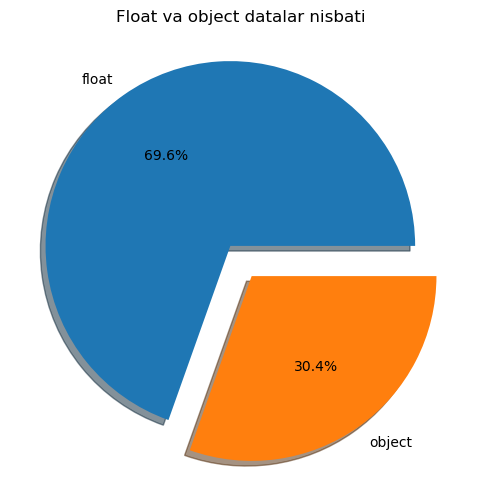

In [34]:
plt.figure(figsize=(8,6))
plt.pie(data_type, labels=['float', 'object'], explode=[0.1,0.1], autopct='%1.1f%%',shadow=True)
plt.title('Float va object datalar nisbati')
plt.show()

GridSpec(6, 6)

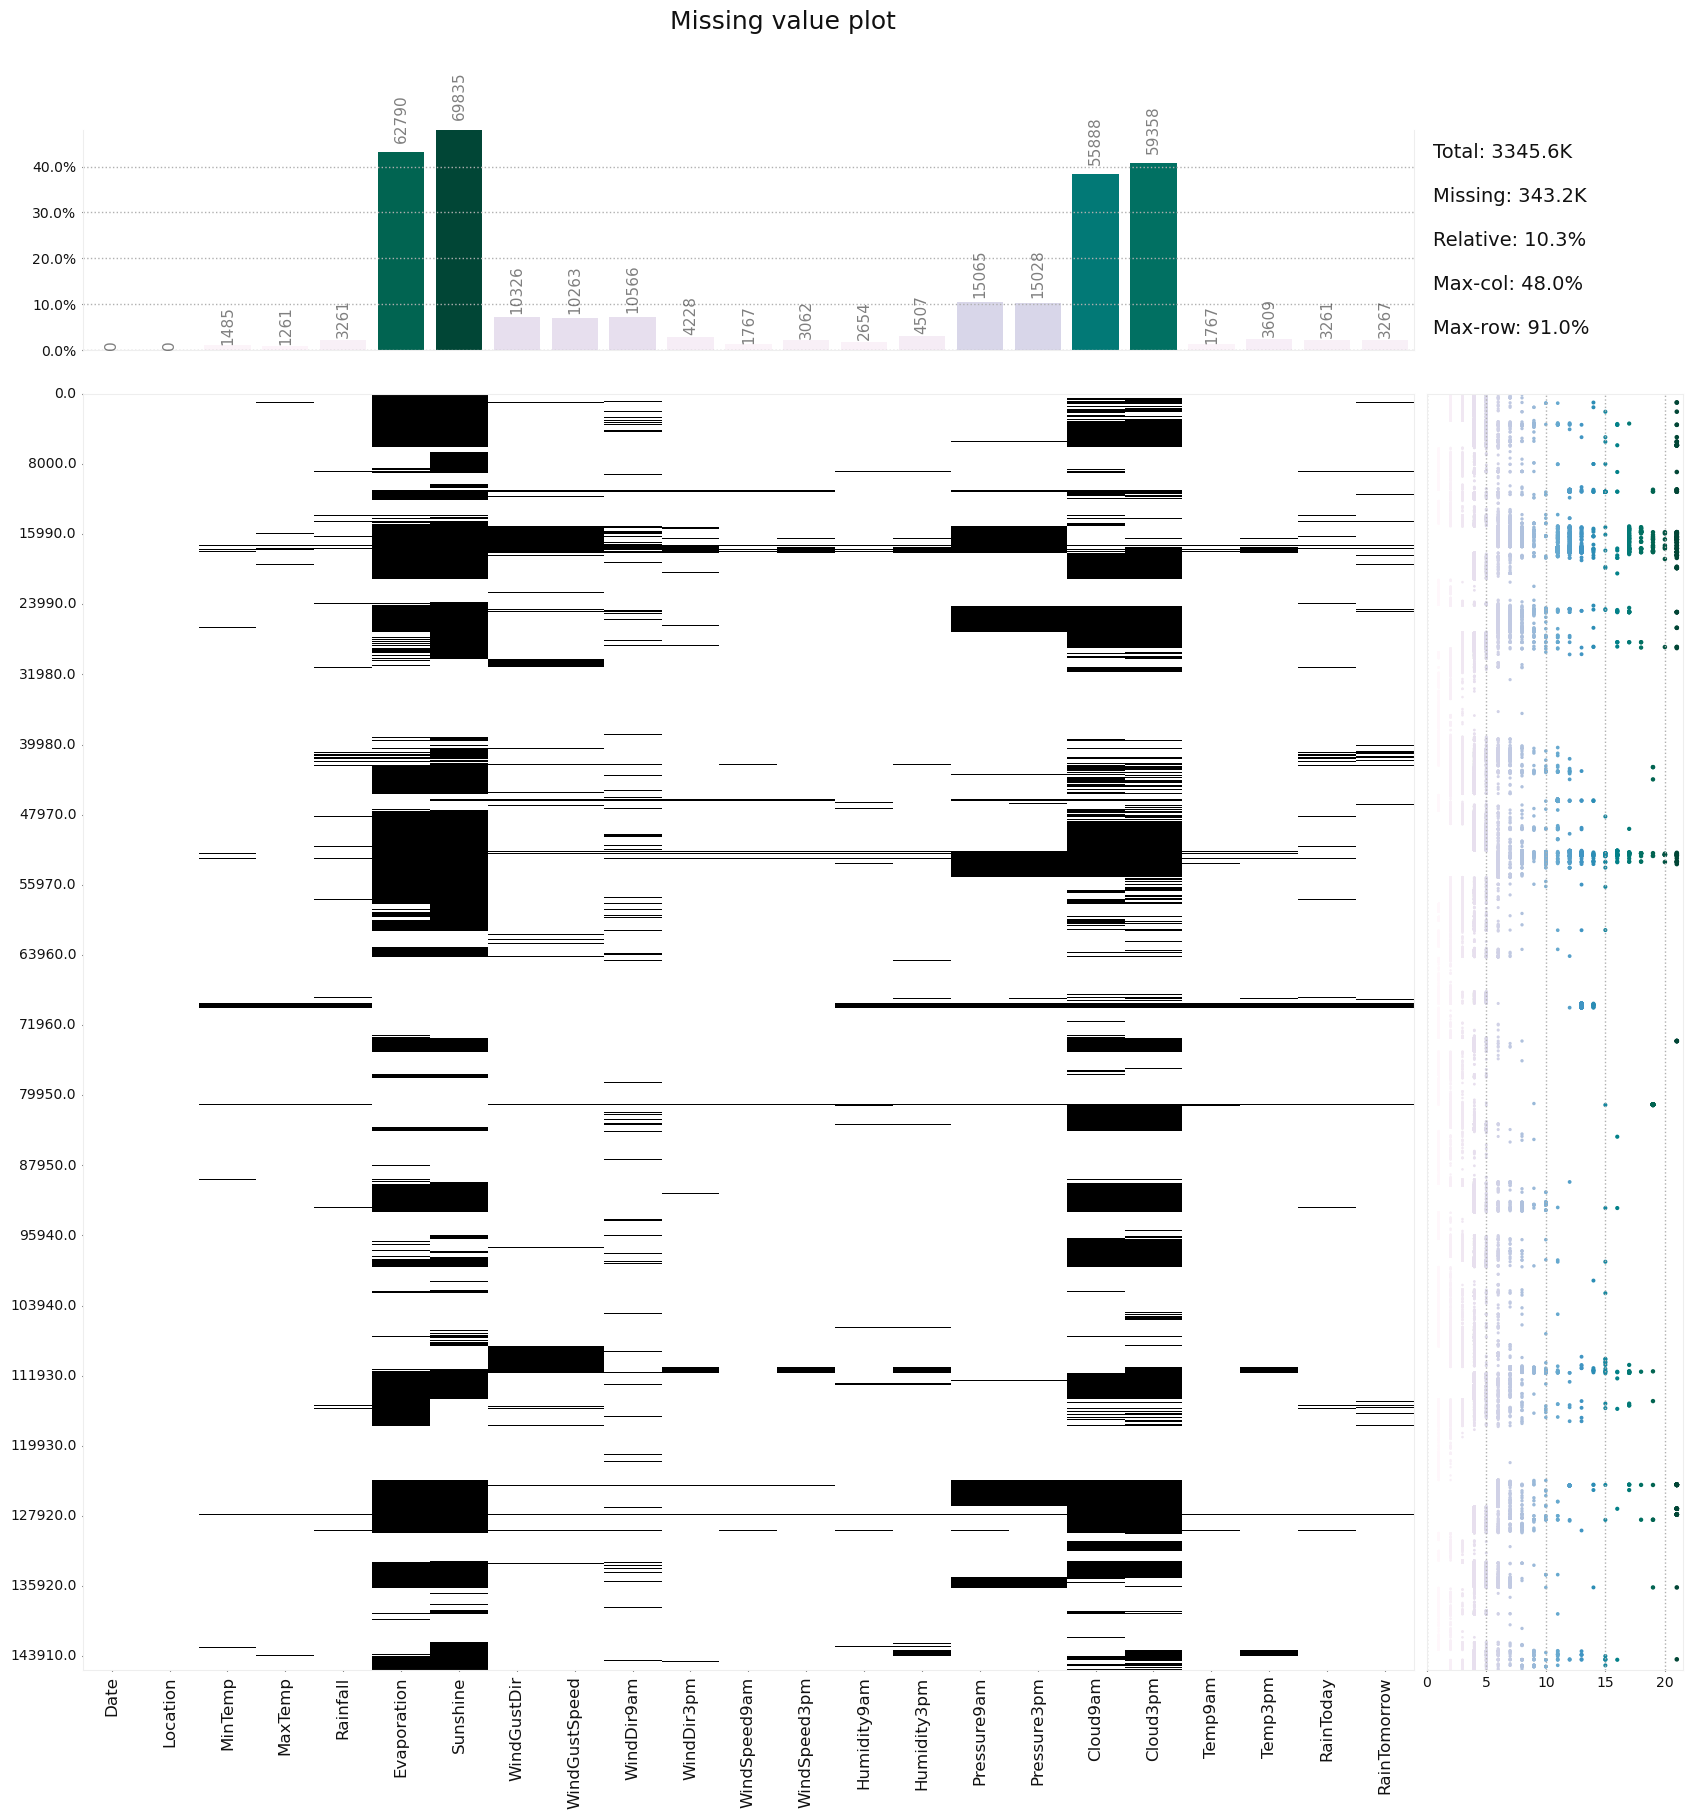

In [58]:
klib.missingval_plot(df)

# df ni toldirish va encodlash

In [88]:
def toldirish(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype=='object':
                df[col].fillna(df[col].mode()[0],inplace=True)
            else:
                df[col].fillna(df[col].mean(),inplace=True)
    return df

In [ ]:
df=toldirish(df)

In [91]:
df['RainTomorrow'].replace({'No': 0, 'Yes': 1},inplace = True)

C:\Users\bunyo\AppData\Local\Temp\ipykernel_18368\779193418.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['RainTomorrow'].replace({'No': 0, 'Yes': 1},inplace = True)


In [92]:
def encodlash(df):
    for col in df.columns:
        if df[col].dtype=='object':
            if df[col].nunique()<=5:
                dummies=pd.get_dummies(df[col],prefix=col, dtype=int)
                df=pd.concat([df.drop(columns=[col]),dummies],axis=1)
            else:
                df[col]=labeller.fit_transform(df[col])
    return df

In [93]:
df = encodlash(df)

In [94]:
def scale_qilish(df):
    num_col=df.select_dtypes(include=['int64','int32','float64']).columns.drop('RainTomorrow')
    df[num_col]=minmax.fit_transform(df[num_col])
    return df

In [95]:
scale_qilish(df)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow,RainToday_No,RainToday_Yes
0,0.115284,0.041667,0.516509,0.523629,0.001617,0.037712,0.524909,0.866667,0.294574,0.866667,...,0.22,0.449587,0.4800,0.888889,0.501103,0.508439,0.522073,0,1.0,0.0
1,0.115575,0.041667,0.375000,0.565217,0.000000,0.037712,0.524909,0.933333,0.294574,0.400000,...,0.25,0.497521,0.4912,0.494162,0.501103,0.514768,0.570058,0,1.0,0.0
2,0.115866,0.041667,0.504717,0.576560,0.000000,0.037712,0.524909,1.000000,0.310078,0.866667,...,0.30,0.447934,0.5056,0.494162,0.222222,0.594937,0.548944,0,1.0,0.0
3,0.116157,0.041667,0.417453,0.620038,0.000000,0.037712,0.524909,0.266667,0.139535,0.600000,...,0.16,0.613223,0.5712,0.494162,0.501103,0.533755,0.612284,0,1.0,0.0
4,0.116448,0.041667,0.613208,0.701323,0.002695,0.037712,0.524909,0.866667,0.271318,0.066667,...,0.33,0.500826,0.4624,0.777778,0.888889,0.527426,0.673704,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,0.998836,0.854167,0.266509,0.533081,0.000000,0.037712,0.524909,0.000000,0.193798,0.600000,...,0.24,0.728926,0.6912,0.494162,0.501103,0.364979,0.533589,0,1.0,0.0
145456,0.999127,0.854167,0.285377,0.568998,0.000000,0.037712,0.524909,0.400000,0.124031,0.600000,...,0.21,0.710744,0.6720,0.494162,0.501103,0.381857,0.573896,0,1.0,0.0
145457,0.999418,0.854167,0.327830,0.599244,0.000000,0.037712,0.524909,0.200000,0.240310,0.600000,...,0.24,0.669421,0.6352,0.494162,0.501103,0.415612,0.604607,0,1.0,0.0
145458,0.999709,0.854167,0.384434,0.601134,0.000000,0.037712,0.524909,0.600000,0.170543,0.666667,...,0.24,0.642975,0.6304,0.333333,0.222222,0.470464,0.602687,0,1.0,0.0


In [129]:
preprossed_df = df

# model yaratish

In [97]:
x = df.drop(['RainTomorrow'], axis=1)
y = df['RainTomorrow']

In [99]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=46)

# Decision Tree

In [101]:
DT_Clas.fit(x_train,y_train)

DecisionTreeClassifier()

In [102]:
pred1 = DT_Clas.predict(x_test)

In [103]:
print(classification_report(y_test,pred1))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86     34098
           1       0.51      0.52      0.52      9540

    accuracy                           0.79     43638
   macro avg       0.69      0.69      0.69     43638
weighted avg       0.79      0.79      0.79     43638



# With KFold

In [105]:
from sklearn.model_selection import KFold,cross_val_score

In [110]:
kf = KFold(n_splits=10 ,shuffle=True, random_state=34)
crossing = cross_val_score(DT_Clas, X=x, y=y, cv=kf, scoring='accuracy')

In [111]:
print(np.mean(crossing))

0.7855905403547367


# Random forest

In [112]:
RF_Clas.fit(x_train,y_train)

RandomForestClassifier()

In [113]:
pred2 = RF_Clas.predict(x_test)

In [114]:
print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     34098
           1       0.76      0.49      0.60      9540

    accuracy                           0.85     43638
   macro avg       0.81      0.72      0.75     43638
weighted avg       0.85      0.85      0.84     43638



# With Kfold

In [115]:
kf = KFold(n_splits=10 ,shuffle=True, random_state=32)
crossing = cross_val_score(RF_Clas, X=x, y=y, cv=kf, scoring='accuracy')

In [116]:
print(np.mean(crossing))

0.8564210092121545


# SVC 

In [117]:
svc.fit(x_train,y_train)

SVC()

In [119]:
pred3 = svc.predict(x_test)

In [120]:
print(classification_report(y_test,pred3))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91     34098
           1       0.77      0.42      0.54      9540

    accuracy                           0.85     43638
   macro avg       0.81      0.69      0.73     43638
weighted avg       0.84      0.85      0.83     43638



In [ ]:
kf = KFold(n_splits=10 ,shuffle=True, random_state=32)
crossing = cross_val_score(svc, X=x, y=y, cv=kf, scoring='accuracy')

# Tabulate

In [121]:
from tabulate import tabulate

In [128]:
natija = [
    ['Decision Tree', 79,78.55, 1.30],
    ['Random Forest', 85, 85.60, 5.45],
    ['Supert Vector Machine', 85, 'failed', 15.44 ]
]
heads = ['model nomi', 'accuracy', 'accuracy(Kfold)','time_consumption(min)']
table = tabulate(natija, headers=heads, tablefmt='fancy_grid',floatfmt='.2f')
print(table)

╒═══════════════════════╤════════════╤═══════════════════╤═════════════════════════╕
│ model nomi            │   accuracy │ accuracy(Kfold)   │   time_consumption(min) │
╞═══════════════════════╪════════════╪═══════════════════╪═════════════════════════╡
│ Decision Tree         │         79 │ 78.55             │                    1.30 │
├───────────────────────┼────────────┼───────────────────┼─────────────────────────┤
│ Random Forest         │         85 │ 85.6              │                    5.45 │
├───────────────────────┼────────────┼───────────────────┼─────────────────────────┤
│ Supert Vector Machine │         85 │ failed            │                   15.44 │
╘═══════════════════════╧════════════╧═══════════════════╧═════════════════════════╛


In [131]:
out_folder = 'MidTermProject/data/preprocessed'
os.makedirs(out_folder,exist_ok=True)
out_path = os.path.join(out_folder, 'preprossed_df.csv')
df.to_csv(out_path,index=False)